<a href="https://colab.research.google.com/github/soumya-statistics-11/Explainable-AI-for-Cancer-Drug-Sensitivity-Prediction/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("/content/GDSC_DATASET.csv")

In [8]:
df.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242035 entries, 0 to 242034
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                242035 non-null  int64  
 1   CELL_LINE_NAME                           242035 non-null  object 
 2   TCGA_DESC                                240968 non-null  object 
 3   DRUG_ID                                  242035 non-null  int64  
 4   DRUG_NAME                                242035 non-null  object 
 5   LN_IC50                                  242035 non-null  float64
 6   AUC                                      242035 non-null  float64
 7   Z_SCORE                                  242035 non-null  float64
 8   GDSC Tissue descriptor 1                 232669 non-null  object 
 9   GDSC Tissue descriptor 2                 232669 non-null  object 
 10  Cancer Type (matching TCGA label

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
COSMIC_ID,0
CELL_LINE_NAME,0
TCGA_DESC,1067
DRUG_ID,0
DRUG_NAME,0
LN_IC50,0
AUC,0
Z_SCORE,0
GDSC Tissue descriptor 1,9366
GDSC Tissue descriptor 2,9366


In [12]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

In [13]:
df.isnull().sum()

,0
COSMIC_ID,0
CELL_LINE_NAME,0
TCGA_DESC,0
DRUG_ID,0
DRUG_NAME,0
LN_IC50,0
AUC,0
Z_SCORE,0
GDSC Tissue descriptor 1,0
GDSC Tissue descriptor 2,0


In [14]:
df['LN_IC50'].describe()

,LN_IC50
count,242035.000000
mean,2.817111
std,2.762191
min,-8.747724
25%,1.508054
50%,3.236744
75%,4.700111
max,13.820189


In [15]:
median_ic50 = df['LN_IC50'].median()

df['Response'] = (df['LN_IC50'] < median_ic50).astype(int)

In [16]:
df['Response'].value_counts()

,count
Response,
0,121018
1,121017


In [17]:
df['Response'].value_counts(normalize=True)*100

,proportion
Response,
0,50.000207
1,49.999793


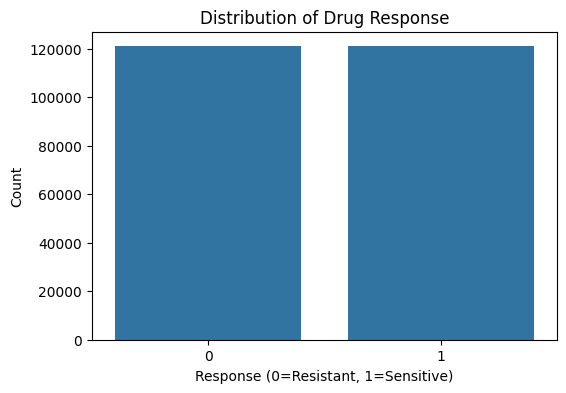

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Response",data=df)
plt.title('Distribution of Drug Response')
plt.xlabel('Response (0=Resistant, 1=Sensitive)')
plt.ylabel('Count')
plt.show()

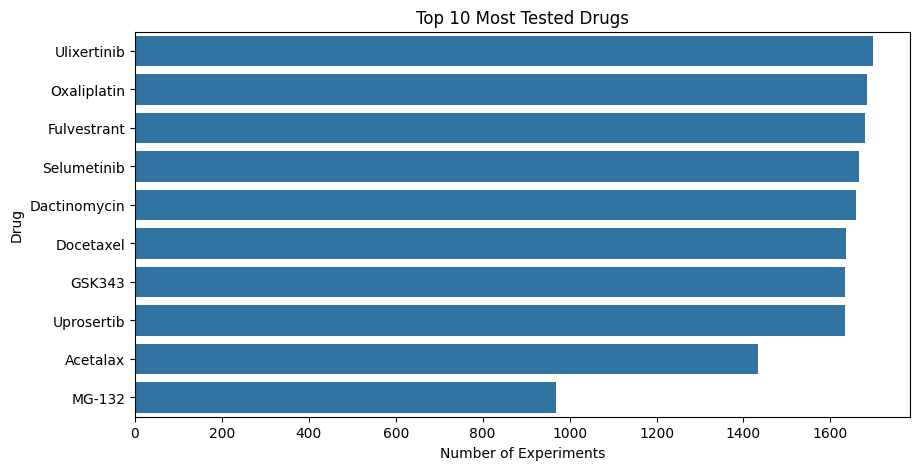

In [19]:
top_drugs=df["DRUG_NAME"].value_counts().head(10)
top_drugs
plt.figure(figsize=(10,5))
sns.barplot(x=top_drugs.values, y=top_drugs.index)

plt.title('Top 10 Most Tested Drugs')
plt.xlabel('Number of Experiments')
plt.ylabel('Drug')
plt.show()

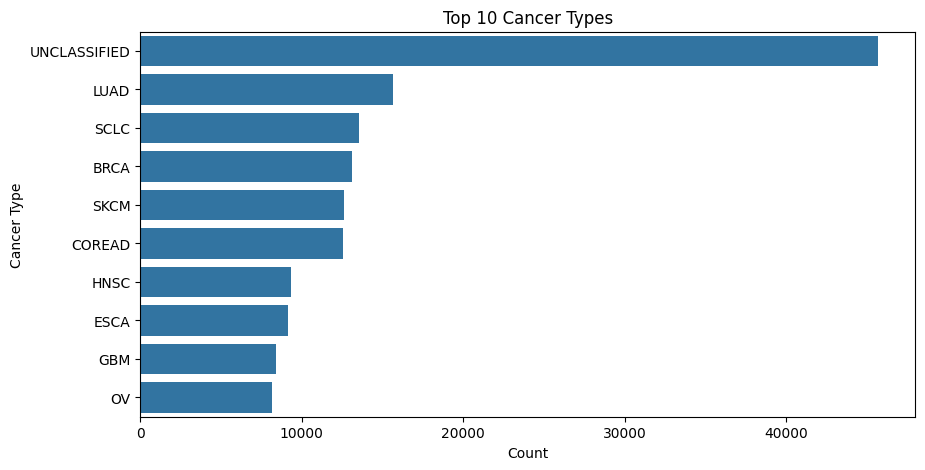

In [20]:
top_cancers = df['TCGA_DESC'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cancers.values, y=top_cancers.index)

plt.title('Top 10 Cancer Types')
plt.xlabel('Count')
plt.ylabel('Cancer Type')
plt.show()

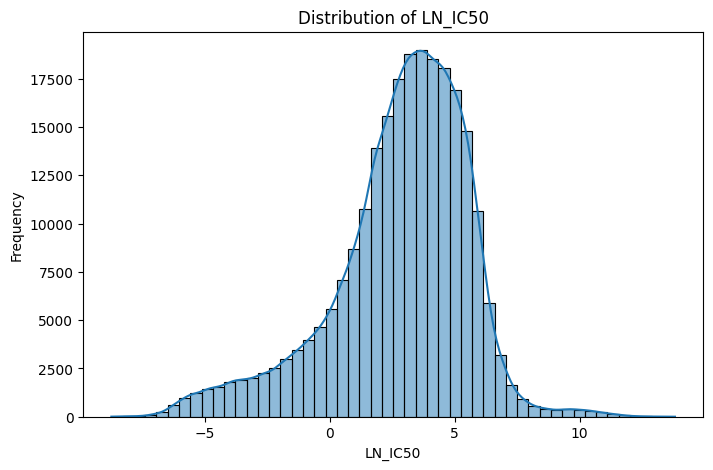

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['LN_IC50'], bins=50, kde=True)

plt.title('Distribution of LN_IC50')
plt.xlabel('LN_IC50')
plt.ylabel('Frequency')

plt.show()

In [25]:
cancer_response=(
    df.groupby("TCGA_DESC")["LN_IC50"]
    .mean()
    .sort_values()
    .head(10)
)
print(cancer_response)

TCGA_DESC
CLL             1.266116
LAML            1.563069
DLBC            1.572369
ALL             1.603867
LCML            1.621284
MM              1.976026
ACC             2.196470
MB              2.407767
NB              2.409070
UNCLASSIFIED    2.529922
Name: LN_IC50, dtype: float64


/tmp/ipykernel_1822/2670656791.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


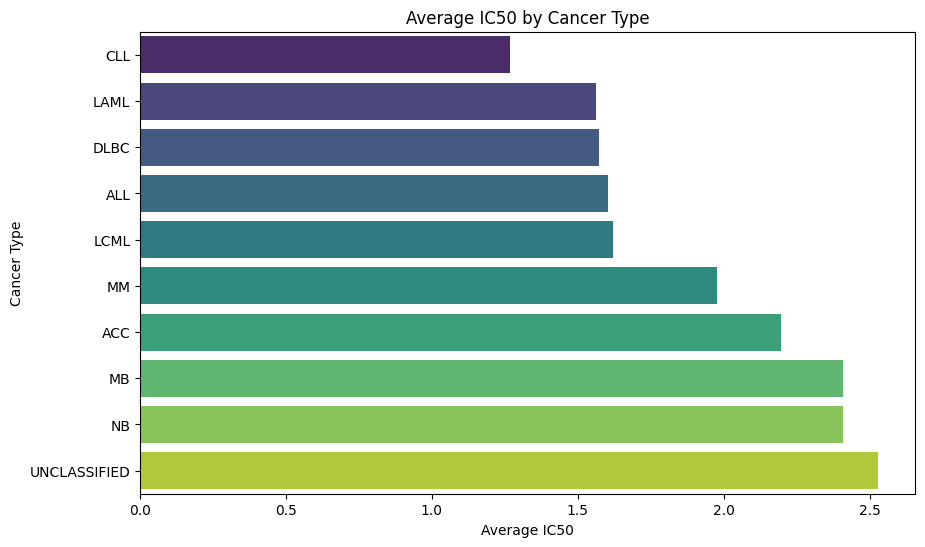

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=cancer_response.values,
    y=cancer_response.index,
    palette="viridis"
)
plt.title("Average IC50 by Cancer Type")
plt.xlabel("Average IC50")
plt.ylabel("Cancer Type")
plt.show()

In [32]:
drug_response=(
    df.groupby("DRUG_NAME")["LN_IC50"]
    .mean()
    .sort_values()
    .head(10)
)
print(drug_response)


DRUG_NAME
Romidepsin             -5.239111
Bortezomib             -4.737909
Sepantronium bromide   -4.158581
Dactinomycin           -3.771855
Vinblastine            -3.491814
SN-38                  -3.426620
Docetaxel              -3.415391
Daporinad              -3.385028
Paclitaxel             -3.095117
Vinorelbine            -2.999885
Name: LN_IC50, dtype: float64


/tmp/ipykernel_1822/426948317.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


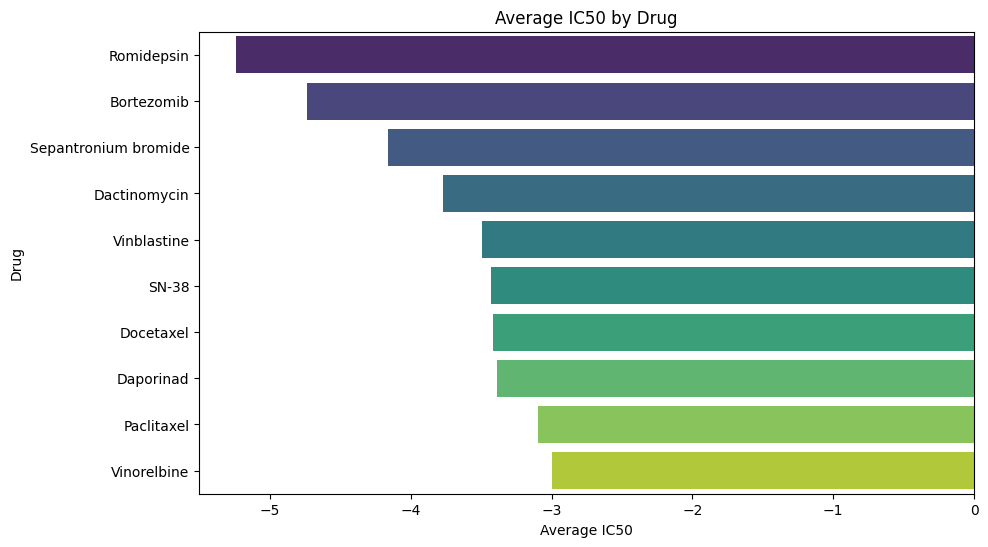

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=drug_response.values,
    y=drug_response.index,
    palette="viridis"
)
plt.title("Average IC50 by Drug")
plt.xlabel("Average IC50")
plt.ylabel("Drug")
plt.show()


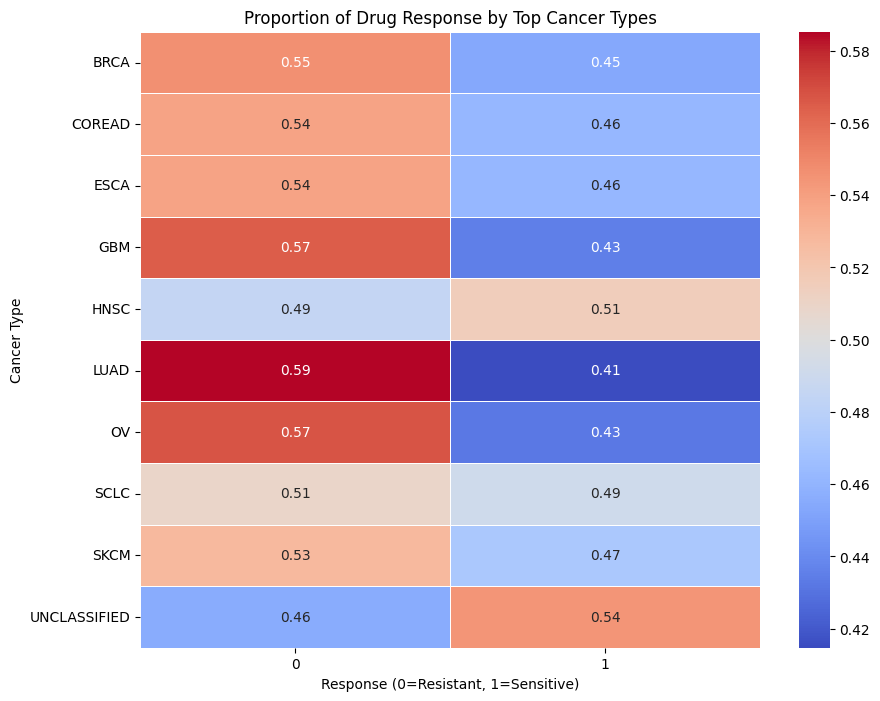

In [35]:
num_top_cancers = 10
top_cancers_list = df['TCGA_DESC'].value_counts().head(num_top_cancers).index.tolist()

filtered_df = df[df['TCGA_DESC'].isin(top_cancers_list)]

response_proportions = filtered_df.groupby('TCGA_DESC')['Response'].value_counts(normalize=True).unstack(fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(response_proportions, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title('Proportion of Drug Response by Top Cancer Types')
plt.xlabel('Response (0=Resistant, 1=Sensitive)')
plt.ylabel('Cancer Type')
plt.show()